# Legislative election 2021

In [2]:
%matplotlib inline

import numpy as np
import pylab as plt
import pandas as pd

In [3]:
# Load data for a given year

def loaddata(year, verbose=True):
    table = pd.read_csv(f'../../data/{year}.csv.zip')
        
    colFilter = ['ПУТИН', 'Путин', 'Единая Россия', 'ЕДИНАЯ РОССИЯ', 'Медведев', 'ДА']
    col = [col for col in table.columns if any([f in col for f in colFilter])]
    assert len(col) == 1
    leader = np.squeeze(table[col].values)
    
    colFilter = ['Число избирателей, включенных', 'Число избирателей, внесенных',
                 'Число участников голосования, включенных']
    col = [col for col in table.columns if any([f in col for f in colFilter])]
    assert len(col) == 1
    voters = np.squeeze(table[col].values)
    
    if year != 2020:
        colFilter = ['бюллетеней, выданных']                # should select 3 columns
        col = [col for col in table.columns if any([f in col for f in colFilter])]
        assert len(col) == 3
    else:
        colFilter = ['Число бюллетеней, содержащихся']
        col = [col for col in table.columns if any([f in col for f in colFilter])]
        assert len(col) == 1
    given = np.sum(table[col].values, axis=1)

    if year != 2020:
        colFilter = ['действительных', 'недействительных']  # should select 2 columns
        excludeFilter = ['отметок']  # excludes one additional column in the 2000 data
        col = [col for col in table.columns if any([f in col for f in colFilter]) and 
                                               all([f not in col for f in excludeFilter])]
        assert len(col) == 2
    else:
        colFilter = ['Число бюллетеней, содержащихся']
        col = [col for col in table.columns if any([f in col for f in colFilter])]
        assert len(col) == 1
    received = np.sum(table[col].values, axis=1)
    
    regions = table['region'].values
    tiks    = table['tik'].values
    uiks    = table['uik'].values
    if 'oik' in table.columns:
        oiks = table['oik'].values
    else:
        oiks = []
        
    if verbose:
        print(f'Stations: {np.sum(~np.isnan(leader)):,}')
        print(f'Voters:   {np.sum(voters):,}')
        print(f'Turnout:  {np.sum(given) / np.sum(voters) * 100:.2f}%')
        print(f'Result:   {np.sum(leader) / np.sum(received) * 100:.2f}%')

    return (voters, given, received, leader, regions, tiks, oiks, uiks)

In [4]:
years = np.array([2000, 2003, 2004, 2007, 2008, 2011, 2012, 2016, 2018, 2020, 2021, 2024])

voters = []
given = []
received = []
leader = []
y = []

for i,year in enumerate(years):
    print('.', end='')
    
    voters_, given_, received_, leader_, _, _, _, _ = loaddata(year, verbose=False)
    
    voters = np.concatenate((voters,voters_))
    given = np.concatenate((given,given_))
    received = np.concatenate((received,received_))
    leader = np.concatenate((leader,leader_))
    
    y = np.concatenate((y, np.ones_like(voters_)*i))

............

In [5]:
ind = ~np.isnan(received) & (received > 0) & (given < voters)

np.random.seed(42)

noise = np.random.rand(np.sum(ind)) - .5
v = (given[ind]+noise)/voters[ind] * 100

noise = np.random.rand(np.sum(ind)) - .5
p = (leader[ind]+noise)/received[ind] * 100

# np.savetxt('all-russian-elections.csv', 
#            np.concatenate((v[:,np.newaxis],p[:,np.newaxis]),axis=1), 
#            delimiter=',',
#            fmt='%.3f',
#            comments='',
#            header="turnout,leader's result")

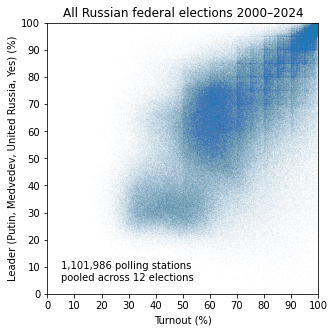

In [7]:
plt.figure(figsize=(8, 4.5), layout="constrained")
plt.gca().set_aspect('equal', adjustable='box')
plt.scatter(v, p, s=.2, alpha=.1, edgecolor='none')
plt.xlim([0, 100])
plt.ylim([0, 100])
plt.xlabel('Turnout (%)')
plt.ylabel('Leader (Putin, Medvedev, United Russia, Yes) (%)')
plt.title('All Russian federal elections 2000–2024')
plt.xticks(np.arange(0,101,10))
plt.yticks(np.arange(0,101,10))

plt.text(5, 5, f'{np.sum(ind):,} polling stations\npooled across {years.size} elections', fontsize=10)

plt.savefig('comet-alltogether-2000-2024.png', dpi=300, facecolor="w")